看到這個優勢後，開始放大資產負債表的負債，同時提高自己的資產曝險

更多的資產曝險，帶來更多的資產增值。

In [2]:
pip install matplotlib numpy numpy-financial


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下載繁體中文字型
!wget -O SourceHanSerifTW-VF.ttf https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf

# 加入字型檔
fm.fontManager.addfont('SourceHanSerifTW-VF.ttf')

# 設定字型
#
mpl.rc('font', family='Source Han Serif TW VF')

--2026-05-29 01:48:13--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-05-29 01:48:14--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

SourceHanSerifTW-VF 100%[===================>]  16.07M  --.-

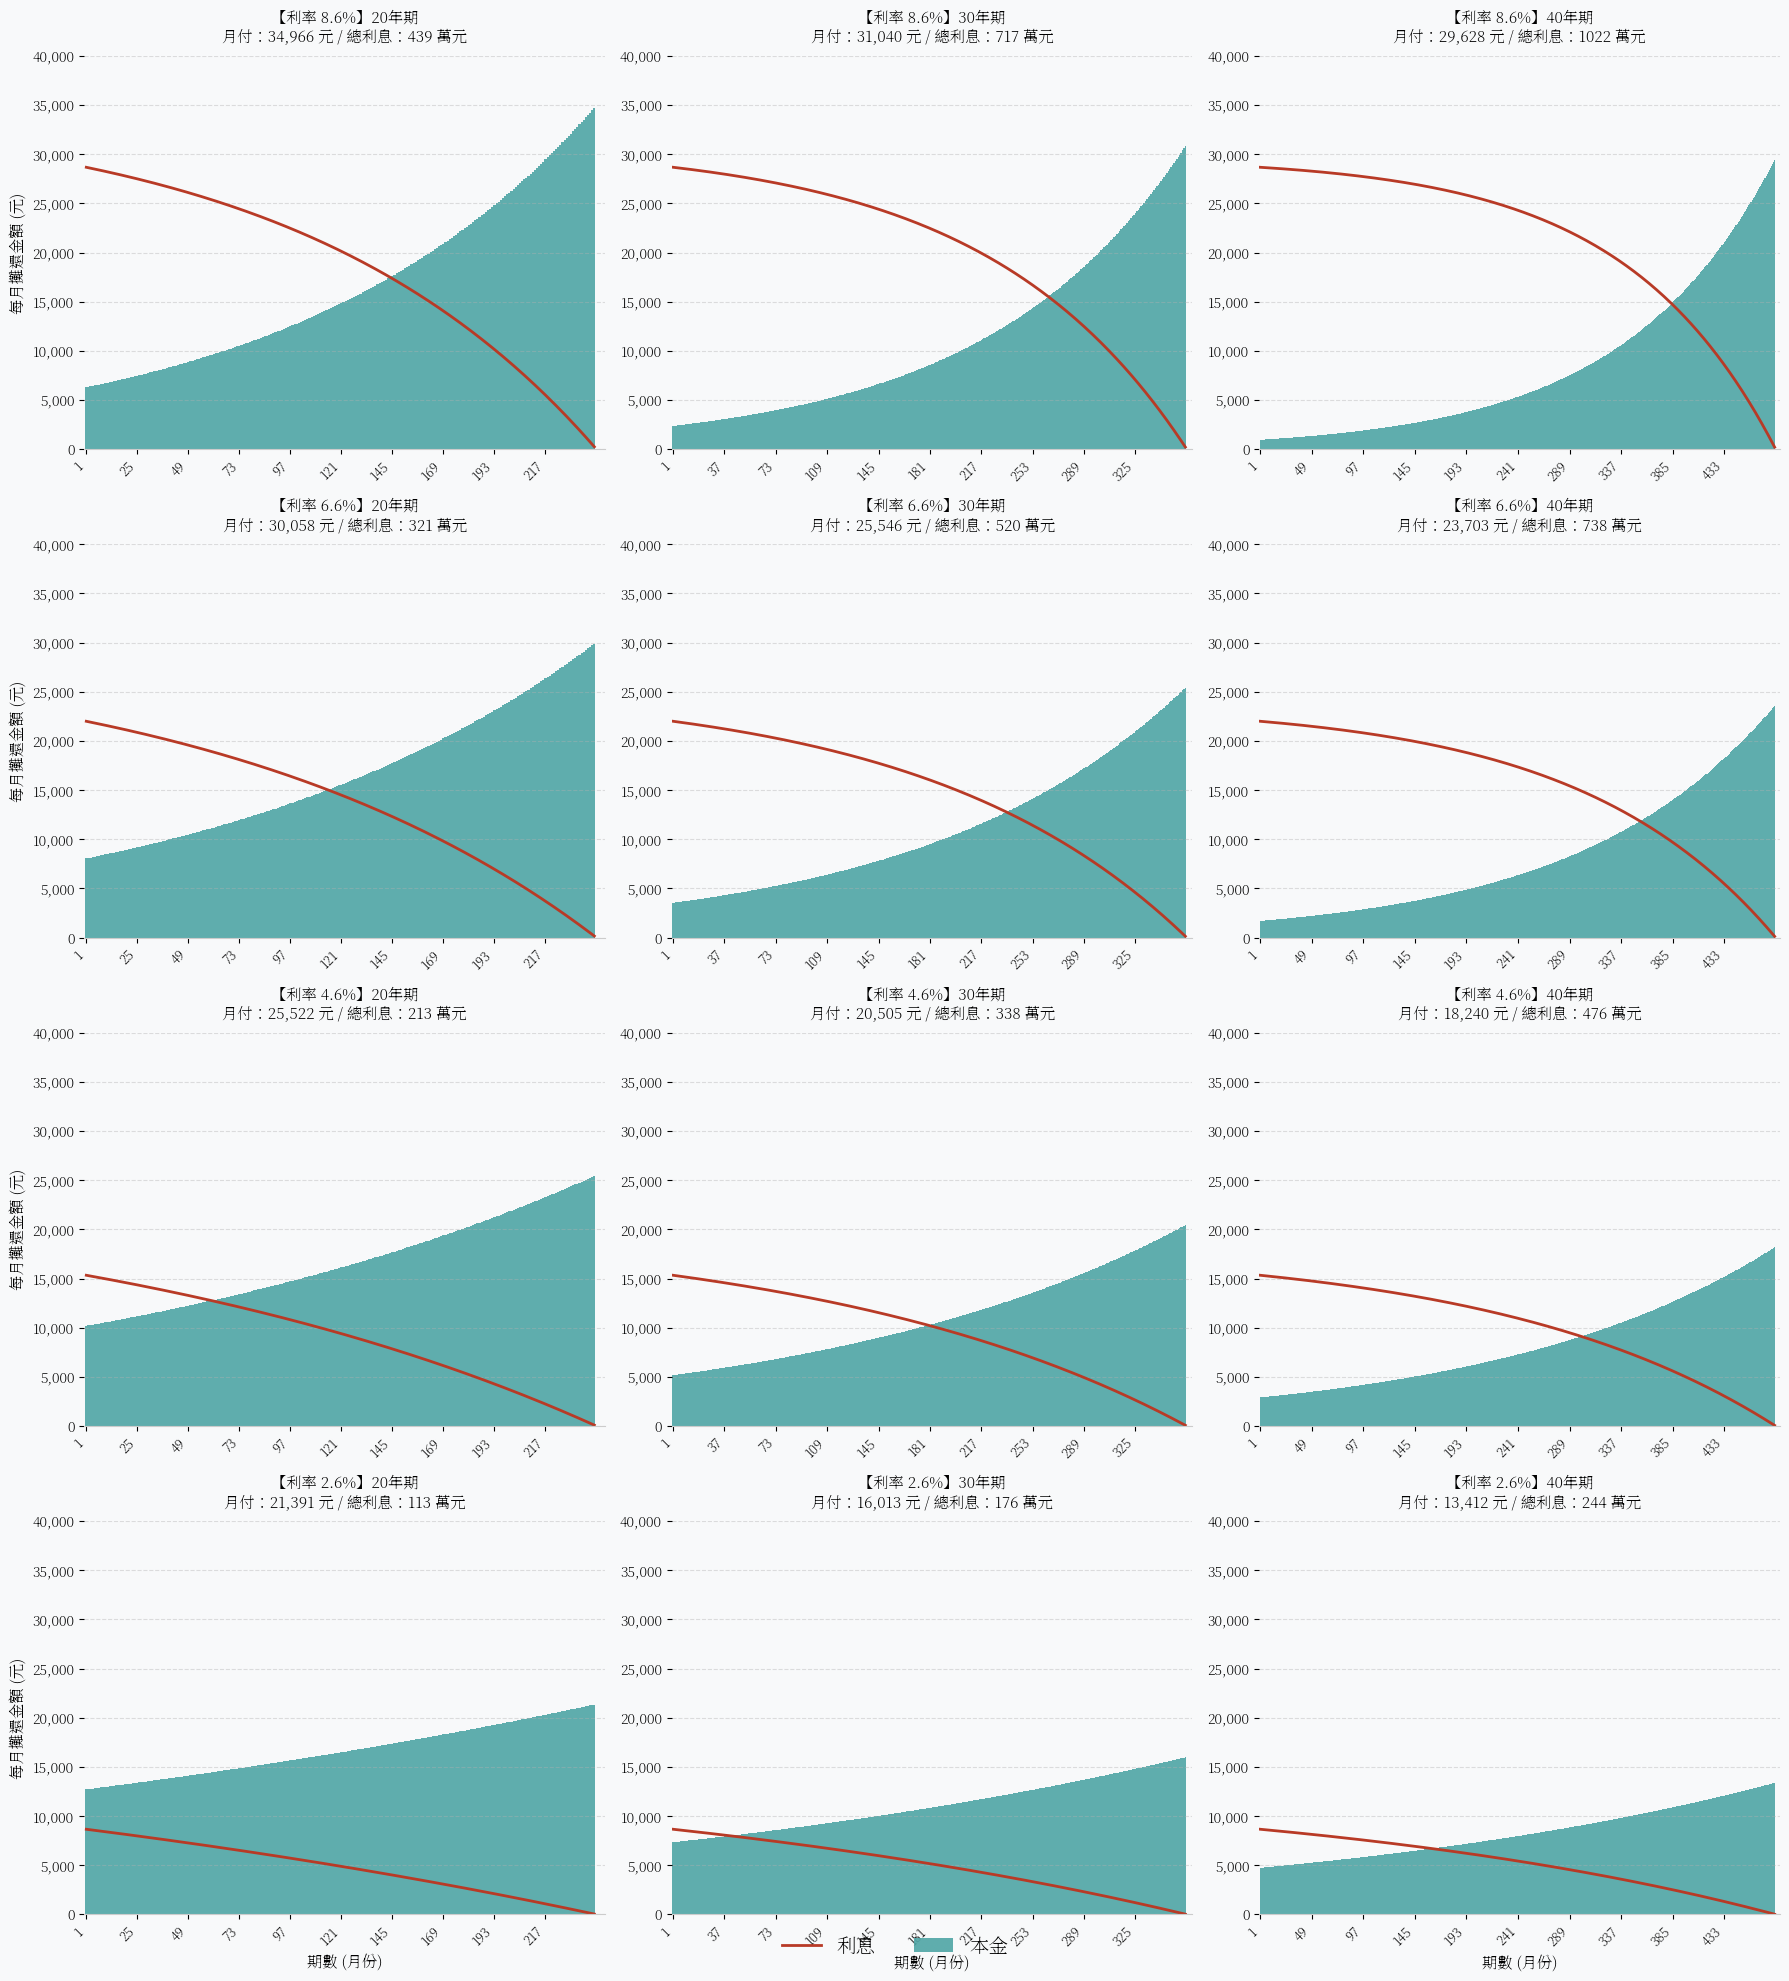

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import numpy_financial as npf

# ---- 1. 設定基本參數 ----
principal = 4000000          # 本金 400 萬
years_list = [20, 30, 40]    # 比較的年期（對應 3 欄 / Columns）
rates_list = [0.086, 0.066, 0.046, 0.026] # 比較的年利率（對應 4 列 / Rows）

# 設定字體（防止中文亂碼）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# ---- 2. 建立 4x3 的畫布 ----
fig, axes = plt.subplots(4, 3, figsize=(18, 20), facecolor='#F8F9FA')

# 使用雙層迴圈動態繪製 12 張子圖
for row_idx, annual_rate in enumerate(rates_list):
    for col_idx, years in enumerate(years_list):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('#F8F9FA')
        
        # 時間與利率計算
        months = years * 12
        monthly_interest_rate = annual_rate / 12
        periods = np.arange(1, months + 1)
        
        # 計算每月固定攤還金額 (PMT)
        pmt = npf.pmt(monthly_interest_rate, months, -principal)
        
        # 計算每期利息、本金與總額
        interest_payments = npf.ipmt(monthly_interest_rate, periods, months, -principal)
        principal_payments = npf.ppmt(monthly_interest_rate, periods, months, -principal)
        total_interest = np.sum(interest_payments)
        
        # 繪製本金（藍綠色長條圖）與利息（紅色折線圖）
        ax.bar(periods, principal_payments, color='#4EA5A5', width=1.0, alpha=0.9, label='本金')
        ax.plot(periods, interest_payments, color='#B83A26', linewidth=2.0, label='利息')
        
        # ---- 3. 設定子圖標題與備註不同利率 ----
        title_text = f'【利率 {annual_rate*100:.1f}%】{years}年期\n月付：{int(pmt):,} 元 / 總利息：{total_interest/10000:.0f} 萬元'
        ax.set_title(title_text, fontsize=11, pad=10, weight='bold', linespacing=1.3)
        
        # 坐標軸優化
        ax.set_xlim(0, months + 5)
        ax.set_ylim(0, 40000)
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
        # 只有最左邊那一欄顯示 Y 軸標籤
        if col_idx == 0:
            ax.set_ylabel('每月攤還金額 (元)', fontsize=11)
        # 只有最下面那一列顯示 X 軸標籤
        if row_idx == 3:
            ax.set_xlabel('期數 (月份)', fontsize=11)
            
        # 依年期彈性調整 X 軸刻度間距，避免太擁擠
        tick_step = 24 if years == 20 else (36 if years == 30 else 48)
        x_ticks = np.arange(1, months + 1, tick_step)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticks, rotation=45, ha='right', fontsize=9)
        
        # 隱藏外框，保持現代感
        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color('#CCCCCC')
        ax.grid(axis='y', linestyle='--', alpha=0.4)

# ---- 4. 統一設定下方的通用圖例 ----
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=14, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout()
# 稍微挪出底部空間給通用圖例
plt.subplots_adjust(bottom=0.04)
plt.show()